In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import randint

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, precision_score

# Preprocessing Pipeline Plan

- Limit observations to only the first encounter
- Drop additional prescribed medication due to limited clinical relevance
- Conduct feature decomposition on insulin and metformin to include a binary flag for being prescribed the medication and an ordinal encoding for the change
- Create train, validation and test splits
- Preprocess features
    - Convert data types (admission source, admission type)
    - Scale numeric features
    - Encode categoricals (OHE and ordinal)
    - Encode target (multi-class, binary)

## Experimenting with Feature Decomposition

Decomposing the insulin and metformin columns into two each: one binary flag to indicate if someone is on the drug at all, another ordinal encoding encoding if the patient is on the drug to indicate if there was a change in dosing.

In [3]:
features = pd.read_parquet("data/diabetes_features.parquet")
target = pd.read_parquet("data/diabetes_target.parquet")

### Limiting the Data to the First Encounter Only

In [4]:
# Creating a dataframe for selecting first encounters
splitting_df = features.copy()
splitting_df['target'] = (target['readmitted'] == "<30").astype(int)

# Keeping only the first encounter per patient_nbr
split_df = splitting_df.drop_duplicates('patient_nbr', keep='first')

### Preparing Features

Binary and Ordinal Splits for Insulin and Metformin

In [5]:
# Creating a feature to indicate if a patient is not on insulin or metformin
split_df['missing_insulin'] = (split_df.insulin == "No").astype(int)
split_df['missing_metformin'] = (split_df.metformin == "No").astype(int)

# Creating a dictionary to encode changes in insulin and metformin
encode_dict = {'No': 0,
               "Steady": 0,
               "Up": 1,
               "Down": -1}

# Applying the encoding to engineer new features
split_df['metformin_change'] = split_df['metformin'].apply(lambda x: encode_dict[x])
split_df['insulin_change'] = split_df['insulin'].apply(lambda x: encode_dict[x])

Binary missingness encoding for weight

In [6]:
split_df['missing_weight'] = (split_df['weight'] == "?").astype("int")

Binary indicator for missingness to one-hot encode:
- medical_specialty
- payer_code

In [7]:
# Utility function for encoding missing values in a column for one-hot encoding
def missing_cleaner(x, missing_code, encoding=""):
    if x == missing_code:
        return encoding
    else:
        return x

split_df['payer_code_cleaned'] = split_df['payer_code'].apply(missing_cleaner, args=("?", "missing_payer"))
split_df['medical_specialty_cleaned'] = split_df['medical_specialty'].apply(missing_cleaner, args=("?", "missing_medical_specialty"))

Binary indicator and ordinal encoding for A1C and max_glu_serum

In [8]:
split_df['missing_a1c'] = (split_df['A1Cresult'] == "None").astype("int")
split_df['missing_max_glu_serum'] = (split_df['max_glu_serum'] == "None").astype("int")

#### Creating Train and Test Splits

In [9]:
# List of features to drop
drop_features = ['patient_nbr', 'encounter_id', 'target',
                 'repaglinide', 'nateglinide', 'chlorpropamide',
                 'glimepiride', 'acetohexamide', 'glipizide',
                 'glyburide', 'tolbutamide',
                 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
                 'tolazamide', 'examide', 'citoglipton', 'insulin',
                 'glyburide.metformin', 'glipizide.metformin',
                 'glimepiride.pioglitazone', 'metformin.rosiglitazone',
                 'metformin.pioglitazone', 'metformin', 'insulin',
                 'A1Cresult', 'weight', 'diag_1', 'diag_2', 'diag_3',
                 'max_glu_serum', 'change']

# Building X & y dataframes
y = split_df['target']
X = split_df.drop(columns=drop_features)

# Creating train and test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

## Setting up the Pipeline

Features for scaling:
- time_in_hospital
- num_lab_procedures
- num_procedures
- num_medications
- number_outpatient
- number_inpatient
- number_diagnoses

Features for OHE:
- race
- gender
- admission_type_id
- dicharge_disposition_id
- admission_source_id
- payer_code
- medical_specialty

Features for ordinal encoding:
- Age
- Metformin (already encoded)
- Insulin (already encoded)

#### OHE Columns

In [10]:
OHEFEATURES = ['race', 'gender', 'admission_type_id',
               'discharge_disposition_id', 'admission_source_id',
               'payer_code', 'medical_specialty']

# Pipeline for OHE
ohe_pipeline = Pipeline([('handle_outliers', SimpleImputer(strategy='most_frequent')),
                         ('encoding', OneHotEncoder(handle_unknown='ignore',
                                                    min_frequency=0.01,
                                                    sparse_output=False
                                                    ))])

#### Columns for Scaling

In [11]:
SCALING_FEATURES = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                    'num_medications', 'number_outpatient', 'number_inpatient', 'number_diagnoses']

# Pipeline for Scaling
scaling_pipeline = Pipeline([('scaling', MinMaxScaler())])

#### Columns for Ordinal Encoding

In [12]:
# Setting up a list of columns for ordinal encoding
ORDINAL_COLS = ['age']

# Creating a list of categories for the age column
age_categories = sorted(split_df['age'].unique())

# Setting up a pipeline for ordinal encoding
ordinal_pipeline = Pipeline([('ordinal_encoding', OrdinalEncoder(categories=[age_categories]))])

#### Setting up the Column Transformer

In [13]:
ct = ColumnTransformer([('OHE', ohe_pipeline, OHEFEATURES),
                        ('scaling', scaling_pipeline, SCALING_FEATURES),
                        ('ordinal_encoding', ordinal_pipeline, ORDINAL_COLS)])

# Setting the output to return a pandas dataset
ct.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OHE', ...), ('scaling', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

## Fitting the Model

In [14]:
# Setting up a dictionary of models
models = {'random_forest': RandomForestClassifier(class_weight='balanced'),
          'log_reg': LogisticRegression()}

# Creating the parameter grid
param_grid = {
    'random_forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 5, 10],
        'model__min_samples_split': [2, 5]
    },
    'log_reg': {
        'model__C': np.logspace(-3, 2, 6)
    }
}

# Setting up a scoring dictionary
scoring_dict = {
    'average_precision': 'average_precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'precision': make_scorer(precision_score, zero_division=0)
    }

In [15]:
if False:
    # Setting up a StratifiedKFold for cross-validation
    cv = StratifiedKFold(n_splits=5,
                        random_state=42,
                        shuffle=True)

    # Creating a dictionary for CV results
    cv_results = {}


    # Setting up the loop to evaluate the different models across the parameter grids
    for model_name, model in models.items():

        # Pipeline for model training
        model_training_pipeline = Pipeline([('preprocessing', ct),
                                            ('model', model)])

        # Setting up the grid for CV
        grid = GridSearchCV(model_training_pipeline,
                            param_grid=param_grid[model_name],
                            scoring=scoring_dict,
                            refit='average_precision',
                            cv=cv)

        # Storing the results
        cv_results[model_name] = grid.fit(X_train, y_train)

In [16]:
if False:    
    results_df = pd.concat(
        {name: pd.DataFrame(grid.cv_results_) for name, grid in cv_results.items()},
        names=['model']
    ).reset_index(level='model')

    # The columns you actually care about:
    cols = ['model', 'params', 'mean_test_average_precision',
            'mean_test_recall', 'mean_test_roc_auc', 'rank_test_average_precision']
    results_df[cols].sort_values('mean_test_average_precision', ascending=False)

#### CV Findings:

While Logistic regression produces similar results for average precision, its recall is extraoridarily low. This is not acceptable since recall measures how well the model detects patients that are likely to readmit.

Performance of Random Forest on average precision is best with deeper trees and a smaller number of samples for a split. However, these deep trees have a lower recall than shallow trees, suggesting the model is overfitting. Improved recall with a lower number of samples suggests the model may be learning edge cases for a smaller number of patients, or is subject overfitting.

## Model Refinement

Hyperparameter tuning and feature selection

#### Random Grid Search

In [ ]:
# Setting up a new pipeline for hyperparameter tuning
hyperparameter_pipe = Pipeline([('preprocessing', ct),
                                ('model', RandomForestClassifier(
                                    random_state=42,
                                    class_weight='balanced'
                                    ))])

# Creating a randomized parameter grid
rand_hyper_grid = {'model__max_depth': randint(2, 15),
              'model__min_samples_split': randint(2, 10),
              'model__n_estimators': randint(50, 300),
              'model__max_features': ['sqrt', 'log2', 0.3, 0.5]}

# Setting up a random grid search object
random_cv = RandomizedSearchCV(estimator=hyperparameter_pipe,
                               cv=5,
                               param_distributions=rand_hyper_grid,
                               n_iter=20,
                               scoring=scoring_dict,
                               random_state=42,
                               refit='recall')

# Fitting the random grid
random_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': <scipy.stats....t 0x11b188270>, 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_split': <scipy.stats....t 0x11b18b460>, 'model__n_estimators': <scipy.stats....t 0x11b31e750>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'average_precision': 'average_precision', 'precision': make_scorer(p...ro_division=0), 'recall': 'recall', 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :

In [22]:
# Dataframe for CV results
rand_grid_cv_results = pd.DataFrame(random_cv.cv_results_)

rand_grid_cv_results.sort_values('mean_test_recall', ascending=False).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__max_features,param_model__min_samples_split,param_model__n_estimators,params,split0_test_average_precision,...,std_test_roc_auc,rank_test_roc_auc,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,split4_test_precision,mean_test_precision,std_test_precision,rank_test_precision
11,4.587810,0.057545,0.137746,0.007981,4,0.5,8,293,"{'model__max_depth': 4, 'model__max_features':...",0.156705,...,0.011365,10,0.122989,0.122771,0.126707,0.128282,0.131441,0.126438,0.003282,18
14,1.376520,0.006229,0.059026,0.001955,3,0.5,2,109,"{'model__max_depth': 3, 'model__max_features':...",0.149991,...,0.010686,14,0.122989,0.122771,0.126631,0.128282,0.131441,0.126423,0.003280,19
19,0.722395,0.010292,0.043443,0.001128,3,0.5,5,51,"{'model__max_depth': 3, 'model__max_features':...",0.148619,...,0.011283,15,0.123061,0.122771,0.126481,0.128282,0.131441,0.126407,0.003264,20
4,3.362524,0.026354,0.104468,0.002538,5,0.5,9,180,"{'model__max_depth': 5, 'model__max_features':...",0.158179,...,0.011231,8,0.122825,0.122989,0.127780,0.129603,0.132960,0.127231,0.003903,17
15,0.602416,0.013070,0.064318,0.001431,3,log2,2,139,"{'model__max_depth': 3, 'model__max_features':...",0.149656,...,0.009873,13,0.131591,0.126744,0.132514,0.132320,0.136423,0.131918,0.003088,16
18,1.001578,0.012930,0.097661,0.002988,4,log2,2,213,"{'model__max_depth': 4, 'model__max_features':...",0.150083,...,0.009926,11,0.131771,0.126926,0.132693,0.133943,0.136568,0.132380,0.003169,15
16,0.882888,0.012235,0.090603,0.001847,6,log2,5,141,"{'model__max_depth': 6, 'model__max_features':...",0.157017,...,0.008078,3,0.131903,0.129290,0.132403,0.136481,0.138844,0.133784,0.003421,14
5,1.149512,0.015999,0.098197,0.001420,7,sqrt,3,137,"{'model__max_depth': 7, 'model__max_features':...",0.162060,...,0.008640,2,0.131597,0.131082,0.134187,0.139225,0.139558,0.135130,0.003637,13
0,1.829852,0.043129,0.068643,0.002860,8,0.5,6,64,"{'model__max_depth': 8, 'model__max_features':...",0.162658,...,0.010463,6,0.131473,0.131546,0.136112,0.136398,0.140938,0.135293,0.003532,12
2,1.867642,0.070581,0.175194,0.002018,8,log2,4,264,"{'model__max_depth': 8, 'model__max_features':...",0.160695,...,0.007511,4,0.135639,0.132710,0.136488,0.139085,0.141230,0.137030,0.002924,11


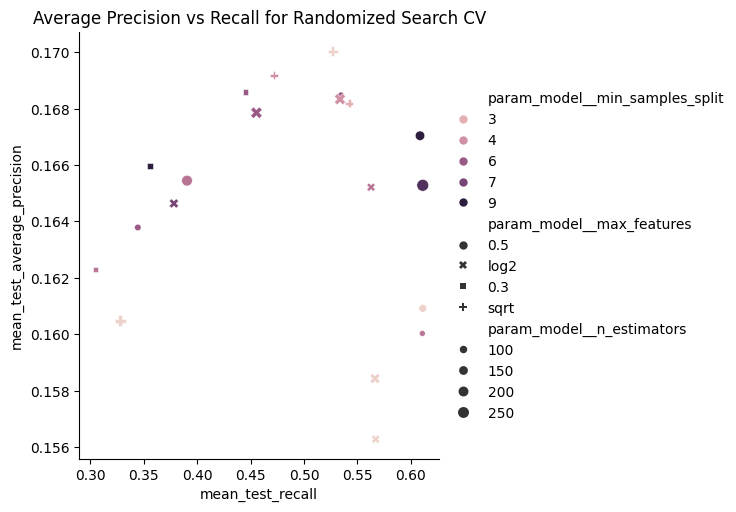

In [39]:
sns.relplot(data=rand_grid_cv_results,
            x='mean_test_recall',
            y='mean_test_average_precision',
            hue='param_model__min_samples_split',
            style='param_model__max_features',
            size='param_model__n_estimators')
plt.title("Average Precision vs Recall for Randomized Search CV")
plt.show()

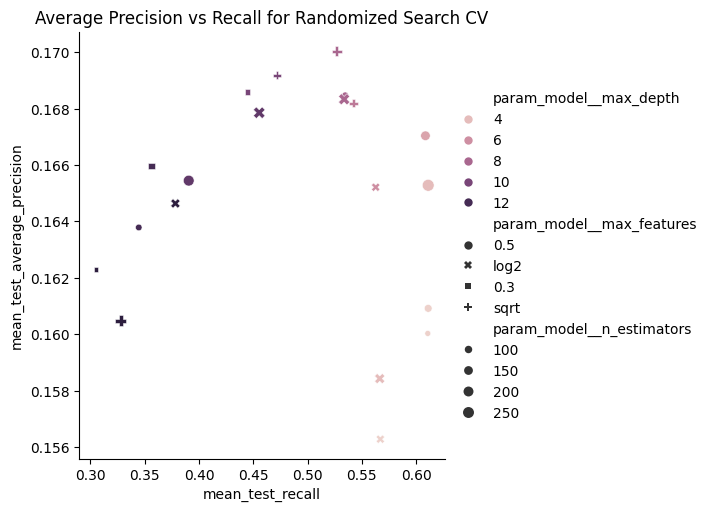

In [42]:
sns.relplot(data=rand_grid_cv_results,
            x='mean_test_recall',
            y='mean_test_average_precision',
            hue='param_model__max_depth',
            style='param_model__max_features',
            size='param_model__n_estimators')
plt.title("Average Precision vs Recall for Randomized Search CV")
plt.show()

#### Random CV Results

- Max depth has a clear impact on model performance: deep trees perform the worst while very shallow trees overfit and precision suffers
- A moderate numbe =r of estimators (~200) provides great recall without a large penalty on precision
- The model performs best with a larger number of parameters (~0.5)
- A high number (~9) of minimum samples per split performs best

#### Regular Grid Search

Searching the smaller space of hyperparameters based on the results from random CV

In [ ]:
# Creating a refined hyperparameter grid based on the results of the random search
refined_hyper_grid = {
    'model__max_depth': [5, 6, 7, 8],
    'model__min_samples_split': [8, 9, 10, 11],
    'model__n_estimators': [175, 200, 225, 250],
    'model__max_features': [0.4, 0.5, 0.6]
}

# Running the tune
refined_cv = GridSearchCV(hyperparameter_pipe,
                         cv=5,
                         param_grid=refined_hyper_grid,
                         scoring=scoring_dict,
                         refit='recall')

refined_cv.fit(X_train, y_train)

In [ ]:
refined_cv_results = pd.DataFrame(refined_cv.cv_results_)
pd.to_excel(refined_cv_results, "experiments/refined_cv_results.xlsx", index=False)